In [ ]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Custom modules
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
from spk_feat_cluster_comp_analysis  import *

In [ ]:
cluster_pickle_dir = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/"

### Step 1: Create dataframe with all experiment metadata and clustering results

In [ ]:
#create df for all experiments 
df_master = compile_experiment_results(cluster_pickle_dir)


In [ ]:
df_master


In [ ]:
#sort by cell id
# Create a numeric column for sorting (c1, c2, c10, etc.)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)

# Sort by the numeric ID, then by feature name
df_master = df_master.sort_values(by=['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])



### Step 2: Generate table figure from dataframe 


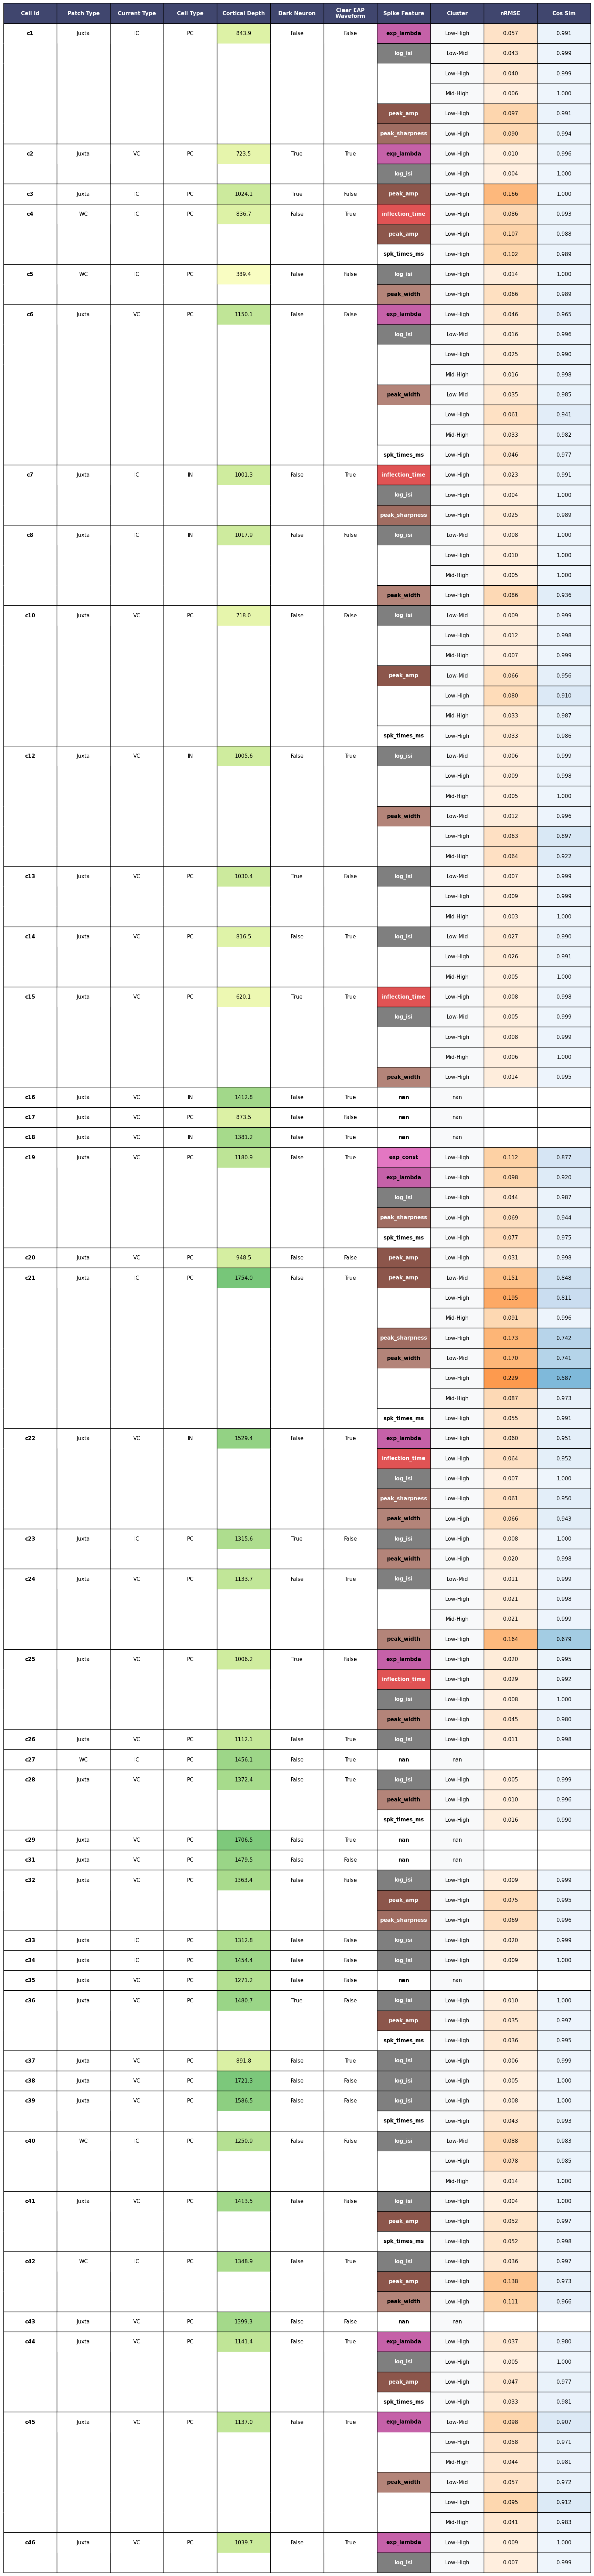

In [6]:

gen_table_fig(df_master)


### Step 3: Patterns for clustering/metadata

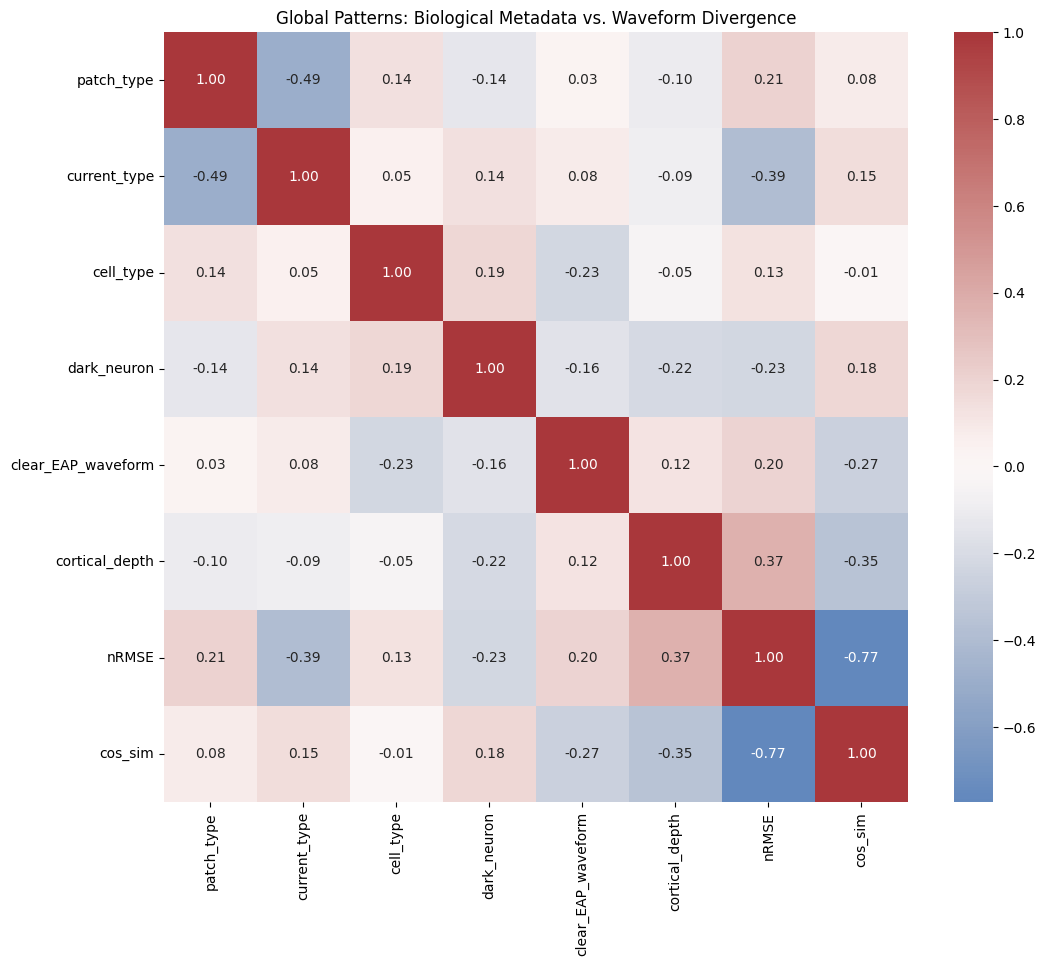

In [7]:

# 1. Encode all metadata for a total correlation check
df_analysis = df_master.copy()
cat_cols = ['patch_type', 'current_type', 'cell_type', 'dark_neuron', 'clear_EAP_waveform']
for col in cat_cols:
    df_analysis[col] = df_analysis[col].astype('category').cat.codes

# 2. Correlation of EVERYTHING
full_metadata = cat_cols + ['cortical_depth', 'nRMSE', 'cos_sim']
corr_matrix = df_analysis[full_metadata].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Global Patterns: Biological Metadata vs. Waveform Divergence")
plt.show()

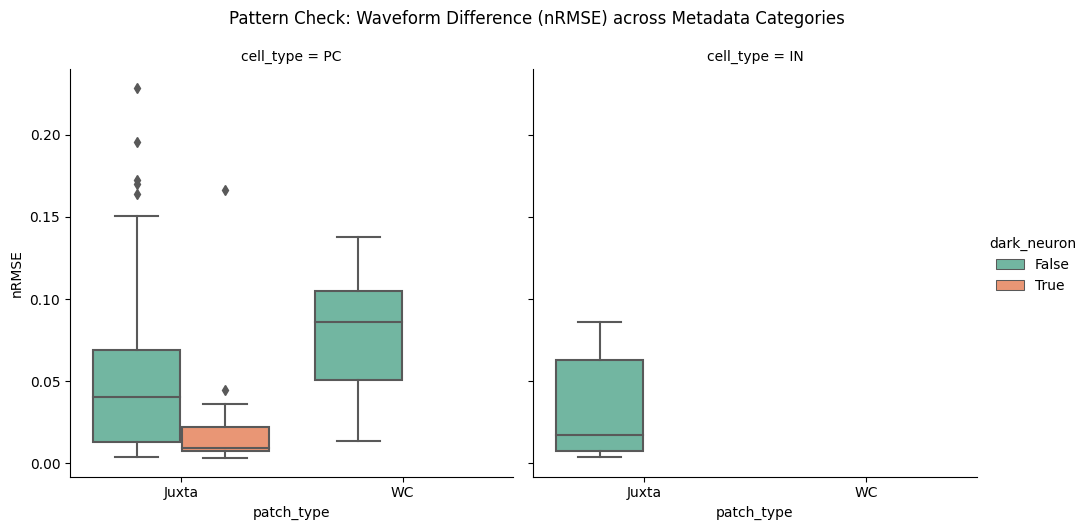

In [8]:
# Faceted boxplot to see nRMSE across Patch Type, Cell Type, and Neuron Status
g = sns.catplot(
    data=df_master, x="patch_type", y="nRMSE", 
    hue="dark_neuron", col="cell_type",
    kind="box", palette="Set2", height=5, aspect=1
)
g.fig.suptitle("Pattern Check: Waveform Difference (nRMSE) across Metadata Categories", y=1.05)
plt.show()

<Figure size 1000x600 with 0 Axes>

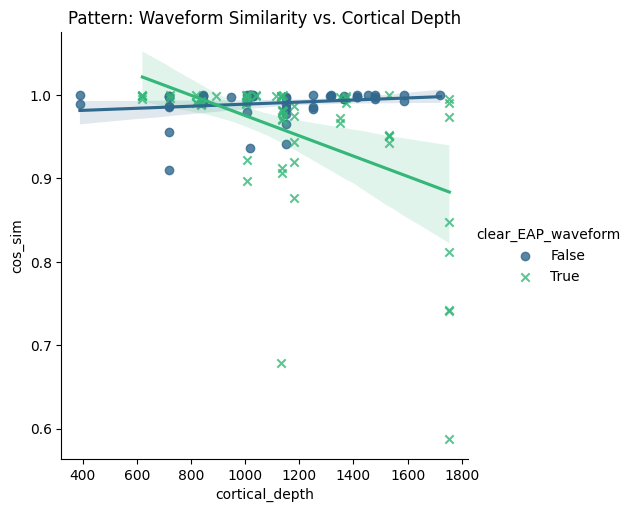

In [9]:
# Correlation between Depth and Similarity, split by Waveform Quality
plt.figure(figsize=(10, 6))
sns.lmplot(
    data=df_master, x="cortical_depth", y="cos_sim", 
    hue="clear_EAP_waveform", markers=["o", "x"], palette="viridis"
)
plt.title("Pattern: Waveform Similarity vs. Cortical Depth")
plt.show()

In [10]:
# Encode booleans/categories to numeric for correlation
df_corr = df_master.copy()
for col in ['dark_neuron', 'clear_EAP_waveform', 'patch_type', 'current_type', 'cell_type']:
    df_corr[col] = df_corr[col].astype('category').cat.codes

corr_matrix = df_corr[metadata_cols + ['nRMSE', 'cos_sim']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Metadata vs. Performance: Global Correlation Patterns")
plt.show()

NameError: name 'metadata_cols' is not defined